# Business Understanding

## 🏬 Project Domain

> Domain: Retail & Customer Analytics<br>
> Sub-Domain: Customer Experience Management & Intelligent Feedback Prediction

Sistem prediksi rating pelanggan pada transaksi supermarket termasuk dalam bidang _customer analytics_ yang memanfaatkan teknik _machine learning_ untuk membantu perusahaan ritel memahami dan meningkatkan pengalaman pelanggan. Dengan mempertimbangkan berbagai fitur transaksi seperti jenis produk, metode pembayaran, harga, jumlah pembelian, waktu transaksi, dan profil pelanggan, sistem ini bertujuan memberikan dukungan keputusan berbasis data untuk meningkatkan layanan dan loyalitas pelanggan.

## ❓ Problem Statements
Masalah yang Dihadapi:
1. Keterbatasan Data Rating dari Pelanggan

    * Tidak semua pelanggan memberikan feedback atau rating setelah transaksi.

    * Hal ini menyulitkan evaluasi layanan secara menyeluruh.

2. Sulitnya Mengukur Kepuasan Pelanggan secara Objektif

    * Pengukuran rating biasanya subjektif dan tidak selalu tersedia dalam skala besar.

    * Tanpa alat bantu, manajemen kesulitan mengidentifikasi area layanan yang perlu ditingkatkan.

3. Kurangnya Alat Prediksi yang Praktis dan Cepat

    * Belum tersedia sistem ringan berbasis web yang mampu memperkirakan rating pelanggan dari data transaksi secara real-time.

4. Minimnya Integrasi Analitik ke Pengambilan Keputusan Operasional

    * Pengambilan keputusan di toko masih sering bersifat reaktif, bukan proaktif berdasarkan prediksi pengalaman pelanggan.

## 🎯 Goals

Membangun sistem berbasis AI (Artificial Neural Network) untuk memprediksi rating pelanggan berdasarkan:

1. Data Transaksi: Harga, jumlah barang, total belanja, pajak, COGS, profit.

2. Data Profil Pelanggan: Jenis kelamin, tipe pelanggan (member/normal), lokasi cabang dan kota.

3. Kebiasaan Belanja: Jenis produk, waktu transaksi, metode pembayaran.

Sistem ini akan memberikan estimasi skor rating (skala 1–10) secara otomatis untuk setiap transaksi.

## 💡 Solution Statements
🔹 Machine Learning Model
Menggunakan model Artificial Neural Network (ANN) untuk memprediksi skor rating berdasarkan data transaksi historis. Model dilatih agar dapat mengenali pola dan fitur yang berkontribusi terhadap kepuasan pelanggan.

🔹 Aplikasi Web (Streamlit)
Membangun aplikasi berbasis Streamlit dengan antarmuka pengguna yang intuitif dan ringan, memungkinkan pengguna menginput data transaksi dan menerima prediksi rating secara instan.

🔹 Optimasi dengan TensorFlow Lite
Model dikonversi ke format TensorFlow Lite (TFLite) agar dapat dijalankan dengan efisien di berbagai perangkat, termasuk komputer ringan di lingkungan toko atau kasir.

# Data Understanding

In [1]:
# prepping
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Import Library yang Dibutuhkan

In [2]:
# Imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('/content/supermarket_sales.csv')
df.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
381,462-78-5240,C,Naypyitaw,Normal,Female,Electronic accessories,26.61,2,2.6610,55.8810,3/19/2019,14:35,Cash,53.22,4.761905,2.6610,4.2
943,449-16-6770,A,Yangon,Normal,Male,Health and beauty,50.79,5,12.6975,266.6475,2/19/2019,14:53,Credit card,253.95,4.761905,12.6975,5.3
569,408-26-9866,C,Naypyitaw,Normal,Female,Sports and travel,73.98,7,25.8930,543.7530,3/2/2019,16:42,Ewallet,517.86,4.761905,25.8930,4.1
69,382-03-4532,A,Yangon,Member,Female,Health and beauty,18.33,1,0.9165,19.2465,2/2/2019,18:50,Cash,18.33,4.761905,0.9165,4.3
805,220-68-6701,A,Yangon,Normal,Female,Home and lifestyle,77.47,4,15.4940,325.3740,3/17/2019,16:36,Cash,309.88,4.761905,15.4940,4.2


## Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [5]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

# Data Preparation

In [6]:
# Pilih fitur dan target dengan nama kolom yang benar
features = ['Branch', 'City', 'Customer type', 'Gender',
            'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total',
            'Payment', 'cogs',
            'gross margin percentage', 'gross income']
target = 'Rating'
X = df[features]
y = df[target]

In [7]:
# Pra-pemrosesan kolom dengan nama kolom yang benar
numerical_features = ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs',
                      'gross margin percentage', 'gross income']
categorical_features = ['Branch', 'City', 'Customer type', 'Gender',
                        'Product line', 'Payment']

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
# Membuat transformer untuk pra-pemrosesan
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Untuk kolom 'Date' dan 'Time', kita bisa lakukan feature engineering lebih lanjut
)

In [9]:
# Scaling untuk target 'Rating'
rating_scaler = MinMaxScaler(feature_range=(1, 10)) # Skalakan ke rentang 1-10
y_scaled = rating_scaler.fit_transform(y.values.reshape(-1, 1))


In [10]:
# Memisahkan data
X_train, X_test, y_train_scaled, y_test_scaled = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

# Menerapkan pra-pemrosesan
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Modeling

In [12]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Output terkontrol di [0, 1]
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# model.fit(X_train_processed, y_train, epochs=20, batch_size=32, validation_split=0.1)
history = model.fit(X_train_processed, y_train_scaled,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.1)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 30.7273 - mae: 4.9089 - val_loss: 27.0554 - val_mae: 4.6212
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29.3773 - mae: 4.7751 - val_loss: 25.9655 - val_mae: 4.5020
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27.2728 - mae: 4.4851 - val_loss: 25.7984 - val_mae: 4.4836
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.9200 - mae: 4.3945 - val_loss: 25.7622 - val_mae: 4.4796
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.7109 - mae: 4.4758 - val_loss: 25.7481 - val_mae: 4.4781
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 26.2441 - mae: 4.4594 - val_loss: 25.7413 - val_mae: 4.4773
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 28.5365 - mae: 4.6601 - val_loss: 25.7371 - val_mae: 4.4769
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27.3287 - mae: 4.5091 - val_loss: 25.7344 - val_mae: 4.4766
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - los

# Evaluation

In [16]:
loss, mae = model.evaluate(X_test_processed, y_test_scaled, verbose = 0)
print(f'Mean Absolute Error pada set pengujian (Rating): {mae}')

Mean Absolute Error pada set pengujian (Rating): 4.33516788482666


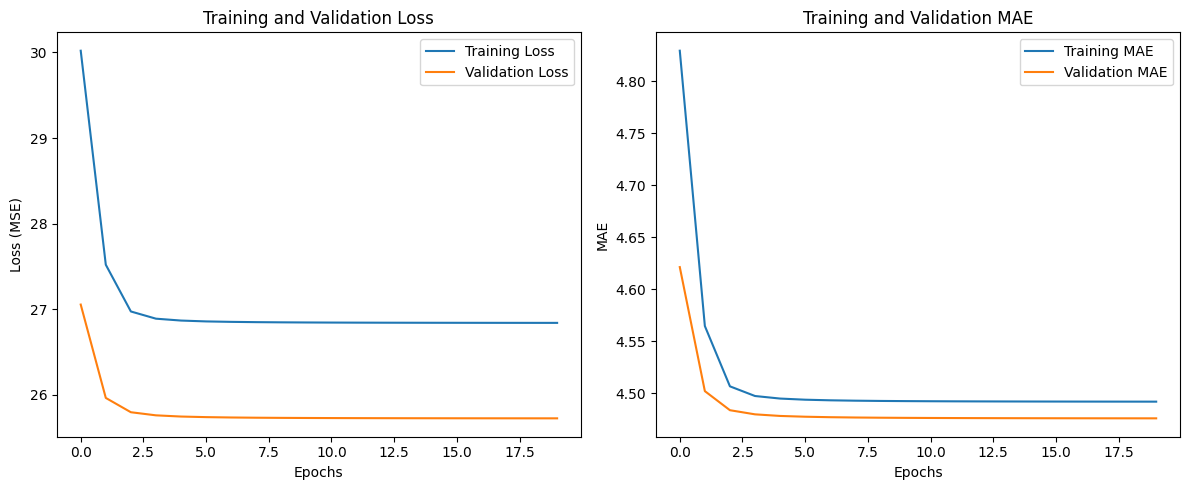

In [17]:
import matplotlib.pyplot as plt

# Asumsikan variabel 'history' menyimpan riwayat pelatihan model
# seperti yang dihasilkan oleh model.fit()

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1) # Ubah subplot agar sesuai
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)') # Sesuaikan label loss
plt.legend()
plt.title('Training and Validation Loss')

# Plot MAE (Mean Absolute Error)
plt.subplot(1, 2, 2) # Ubah subplot agar sesuai
plt.plot(history.history["mae"], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('Training and Validation MAE')

plt.tight_layout() # Untuk mencegah overlap antar subplot
plt.show()

# Deployment

## Model Simulation

In [24]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# Asumsikan 'preprocessor' adalah objek ColumnTransformer yang telah dilatih
# dan 'model' adalah model ANN regresi yang telah dilatih

# Sample input yang disesuaikan dengan fitur-fitur model regresi
sample_input = pd.DataFrame([{
    'Branch': 'A',
    'City': 'Yangon',
    'Customer type': 'Member',
    'Gender': 'Female',
    'Product line': 'Electronics accessories',
    'Unit price': 10.0,
    'Quantity': 1,
    'Tax 5%': 1.0,
    'Total': 11.0,
    'Date': '2019-01-01',
    'Time': '13:00',
    'Payment': 'Ewallet',
    'cogs': 15.0,
    'gross margin percentage': 7.0,
    'gross income': 150.0
}])

# Lakukan pra-pemrosesan yang sama seperti pada data pelatihan
sample_input_processed = preprocessor.transform(sample_input)

# Lakukan prediksi menggunakan model regresi
predicted_rating_scaled = model.predict(sample_input_processed)

# Inverse transform untuk mendapatkan prediksi dalam skala asli
predicted_rating = rating_scaler.inverse_transform(predicted_rating_scaled)[0][0]
print(f"Prediksi Rating: {predicted_rating:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediksi Rating: 4.00


## Save Model

In [25]:
#TFLite:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('regression_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Simpan preprocessor (ColumnTransformer)
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')

# Simpan rating scaler
joblib.dump(rating_scaler, 'rating_scaler.pkl')

Saved artifact at '/tmp/tmpve0al579'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 26), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135427980226832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135427980227600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135427980228560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135427980225296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135427980223952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135427980225680: TensorSpec(shape=(), dtype=tf.resource, name=None)


['rating_scaler.pkl']